# Task 1 Exploring and Identifying Issues

In [289]:
import pandas as pd

df=pd.read_csv("used_cars_messy.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  object 
 2   brand              15661 non-null  object 
 3   model              15661 non-null  object 
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  object 
 6   seller_type        15661 non-null  object 
 7   fuel_type          15661 non-null  object 
 8   transmission_type  15661 non-null  object 
 9   mileage            14376 non-null  object 
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 1.7+ MB


,Unnamed: 0,vehicle_age,engine,max_power,seats,selling_price
count,15661.000000,15661.000000,13792.000000,14862.000000,15218.000000,1.550300e+04
mean,9808.189643,6.036843,1480.489342,100.513582,5.324418,1.032764e+06
std,5642.981540,3.015072,511.446057,42.854632,0.805993,1.607380e+07
min,0.000000,0.000000,793.000000,38.400000,0.000000,5.000000e+02
25%,4901.000000,4.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9858.000000,6.000000,1248.000000,88.500000,5.000000,5.550000e+05
75%,14666.000000,8.000000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,6592.000000,626.000000,9.000000,1.000000e+09


In [290]:
df.duplicated().sum()

np.int64(169)

In [291]:
df[df.duplicated(keep=False)].sort_values("car_name").head(20)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9347,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
5920,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
13398,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
3642,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
867,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0
8441,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0
4958,11969,BMW X5,BMW,X5,7,68000,Dealer,Diesel,Automatic,11.7,2993.0,245.00,5.0,3200000.0
3709,11969,BMW X5,BMW,X5,7,68000,Dealer,Diesel,Automatic,11.7,2993.0,245.00,5.0,3200000.0
4973,7216,Datsun GO,Datsun,GO,4,23142,Dealer,Petrol,Manual,NaN,1198.0,67.00,5.0,360000.0
11616,7216,Datsun GO,Datsun,GO,4,23142,Dealer,Petrol,Manual,NaN,1198.0,67.00,5.0,360000.0


In [292]:
cat_cols=["car_name", "brand", "model", "seller_type", "fuel_type", "transmission_type"]

for col in cat_cols:
    unique_cols=df[col].unique()
    print(f"\nColumn {col} has {len(unique_cols)} unique values: ")
    print(sorted(unique_cols))


Column car_name has 121 unique values: 
['Audi A4', 'Audi A6', 'Audi A8', 'Audi Q7', 'BMW 3', 'BMW 5', 'BMW 6', 'BMW 7', 'BMW X1', 'BMW X3', 'BMW X4', 'BMW X5', 'BMW Z4', 'Bentley Continental', 'Datsun GO', 'Datsun RediGO', 'Datsun redi-GO', 'Ferrari GTC4Lusso', 'Force Gurkha', 'Ford Aspire', 'Ford Ecosport', 'Ford Endeavour', 'Ford Figo', 'Ford Freestyle', 'Honda Amaze', 'Honda CR', 'Honda CR-V', 'Honda City', 'Honda Civic', 'Honda Jazz', 'Honda WR-V', 'Hyundai Aura', 'Hyundai Creta', 'Hyundai Elantra', 'Hyundai Grand', 'Hyundai Santro', 'Hyundai Tucson', 'Hyundai Venue', 'Hyundai Verna', 'Hyundai i10', 'Hyundai i20', 'ISUZU MUX', 'Isuzu D-Max', 'Isuzu MUX', 'Jaguar F-PACE', 'Jaguar XE', 'Jaguar XF', 'Jeep Compass', 'Jeep Wrangler', 'Kia Carnival', 'Kia Seltos', 'Land Rover Rover', 'Lexus ES', 'Lexus NX', 'Lexus RX', 'MG Hector', 'Mahindra Alturas', 'Mahindra Bolero', 'Mahindra KUV', 'Mahindra KUV100', 'Mahindra Marazzo', 'Mahindra Scorpio', 'Mahindra Thar', 'Mahindra XUV300', 'Mahin

In [293]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

## Identified Issues

1. The dataset contains null values in both target and feature columns, which need to be handled appropriately.  
2. `km_driven` and `mileage` are stored as object types and include unnecessary strings like "kmpl", "kmp", "km", and commas — these should be cleaned and converted to numeric.  
3. `seats` and `selling_price` contain unrealistic values. For example, `seats = 0` is invalid, and `selling_price` includes extremely low values (below 10,000) and outliers like 999999999, which should be removed.  
4. `fuel_type`, `brand`, and `seller_type` contain duplicates due to leading/trailing spaces, and `seller_type` also has some typos that need correction.  
5. The dataset contains duplicate rows, which should be removed at the end.  
6. Potential outliers in numerical features (especially `selling_price`, `km_driven`, and `mileage`) should be handled carefully to avoid skewing the model.  

# Task 2 Data Cleaning

In [294]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head(10)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
5,Hyundai i10,Hyundai,i10,12,73000,Dealer,Petrol,Manual,20.36,1197.0,78.90,5.0,190000.0
6,Hyundai i20,Hyundai,i20,12,88000,Dealer,Petrol,Manual,18.5,NaN,80.00,5.0,275000.0
7,Maruti Wagon R,Maruti,Wagon R,7,50000,Individual,Petrol,Manual,20.51,NaN,67.04,5.0,351000.0
8,Ford Freestyle,Ford,Freestyle,2,30000,individual,Diesel,Manual,24.4,1498.0,98.63,5.0,775000.0
9,Maruti Swift Dzire,Maruti,Swift Dzire,10,75220,Dealer,Diesel,Manual,19.3,1248.0,73.90,5.0,390000.0


In [295]:
print(f"Unique values before cleaning: {df['brand'].nunique()}")

df['brand']=df['brand'].str.strip()
print(f"Unique values after cleaning: {df['brand'].nunique()}")

Unique values before cleaning: 80
Unique values after cleaning: 32


In [296]:
print(df['brand'].unique())

['Renault' 'Maruti' 'Honda' 'Mahindra' 'Hyundai' 'Ford' 'Jeep' 'BMW'
 'Jaguar' 'Skoda' 'Volkswagen' 'Tata' 'Mercedes-Benz' 'Datsun' 'Audi'
 'Lexus' 'Toyota' 'Nissan' 'Land Rover' 'Mini' 'Volvo' 'Porsche' 'Kia'
 'MG' 'Isuzu' 'Mercedes-AMG' 'Ferrari' 'Bentley' 'Maserati' 'Force'
 'ISUZU' 'Rolls-Royce']


In [297]:
df.loc[df["brand"]=="ISUZU", "brand"]="Isuzu"
print(df['brand'].unique())

['Renault' 'Maruti' 'Honda' 'Mahindra' 'Hyundai' 'Ford' 'Jeep' 'BMW'
 'Jaguar' 'Skoda' 'Volkswagen' 'Tata' 'Mercedes-Benz' 'Datsun' 'Audi'
 'Lexus' 'Toyota' 'Nissan' 'Land Rover' 'Mini' 'Volvo' 'Porsche' 'Kia'
 'MG' 'Isuzu' 'Mercedes-AMG' 'Ferrari' 'Bentley' 'Maserati' 'Force'
 'Rolls-Royce']


In [298]:
df['seller_type']=df['seller_type'].str.strip().str.title()
print(df['seller_type'].unique())

['Dealer' 'Individual' 'Trustmark Dealer' 'Individul' 'Individuall'
 'Delaer']


In [299]:
typo_change={
    "Delaer": "Dealer",
    "Individul": "Individual",
    "Individuall":"Individual",
}
df['seller_type']=df['seller_type'].replace(typo_change)
print(df['seller_type'].unique())

['Dealer' 'Individual' 'Trustmark Dealer']


In [300]:
df['fuel_type']=df['fuel_type'].str.strip().str.title()
print(df['fuel_type'].unique())

['Diesel' 'Cng' 'Petrol' 'Lpg' 'Electric']


In [301]:
df[df['km_driven'].str.contains("kms")]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
80,Mahindra XUV500,Mahindra,XUV500,6,42000 kms,Dealer,Diesel,Manual,15.1,2179.0,140.00,7.0,950000.0
244,Renault Duster,Renault,Duster,5,62000 kms,Individual,Diesel,Manual,19.87,1461.0,83.80,5.0,700000.0
324,Hyundai i20,Hyundai,i20,9,40000 kms,Dealer,Diesel,Manual,21.9,1396.0,NaN,5.0,435000.0
370,Ford Aspire,Ford,Aspire,5,43652 kms,Dealer,Petrol,Manual,18.16,1196.0,86.80,5.0,430000.0
721,Honda City,Honda,City,10,100000 kms,Individual,Petrol,Manual,17.0,1497.0,118.00,5.0,380000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14403,Honda Civic,Honda,Civic,2,16502 kms,Dealer,Petrol,Automatic,16.5,1799.0,139.46,NaN,2100000.0
14977,Maruti Swift,Maruti,Swift,7,70000 kms,Individual,Petrol,Manual,18.6,1197.0,85.80,5.0,370000.0
15170,Honda Amaze,Honda,Amaze,8,31497 kms,Dealer,Petrol,Manual,18.0,1198.0,86.70,5.0,393000.0
15449,Hyundai i20,Hyundai,i20,3,15000 kms,Dealer,Petrol,Manual,18.6,1197.0,81.83,5.0,660000.0


In [302]:
df['km_driven']=df['km_driven'].str.replace("kms", "")
df['km_driven']=df['km_driven'].str.replace("km", "")
df['km_driven']=df['km_driven'].str.replace(",", "")
df["km_driven"]=df['km_driven'].str.strip()


In [303]:
df[df['km_driven'].str.contains("km")]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [304]:
df['km_driven'].dtypes

dtype('O')

In [305]:
df['km_driven']=df['km_driven'].astype(int)
df['km_driven'].dtypes

dtype('int64')

In [306]:
df['mileage']=df['mileage'].str.replace("kmpl", "").str.replace("kmp", "").str.replace(",", "").str.strip()
df['mileage']=pd.to_numeric(df['mileage'], errors='coerce')
df['mileage'].head()

,mileage
0,19.87
1,33.54
2,NaN
3,15.40
4,16.00


In [307]:
df.isna().sum()/len(df)*100

,0
car_name,0.000000
brand,0.000000
model,0.000000
vehicle_age,0.000000
km_driven,0.000000
seller_type,0.000000
fuel_type,0.000000
transmission_type,0.000000
mileage,8.205095
engine,11.934104


In [308]:
df.dropna(subset=["selling_price"], inplace=True)

In [309]:
mode=df['seats'].mode()[0]
df['seats']=df['seats'].fillna(mode)
print(f"Filled seats with mode: {mode}")

Filled seats with mode: 5.0


In [310]:
for col in ['mileage', 'engine', 'max_power']:
  median = df[col].median()
  df[col]=df[col].fillna(median)
  print(f"Filled {col} with median: {median}")

Filled mileage with median: 19.67
Filled engine with median: 1248.0
Filled max_power with median: 88.5


In [311]:
df.isna().sum()/len(df)*100

,0
car_name,0.0
brand,0.0
model,0.0
vehicle_age,0.0
km_driven,0.0
seller_type,0.0
fuel_type,0.0
transmission_type,0.0
mileage,0.0
engine,0.0


In [312]:
df.duplicated().sum()

np.int64(301)

In [313]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [314]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 15202 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15202 non-null  object 
 1   brand              15202 non-null  object 
 2   model              15202 non-null  object 
 3   vehicle_age        15202 non-null  int64  
 4   km_driven          15202 non-null  int64  
 5   seller_type        15202 non-null  object 
 6   fuel_type          15202 non-null  object 
 7   transmission_type  15202 non-null  object 
 8   mileage            15202 non-null  float64
 9   engine             15202 non-null  float64
 10  max_power          15202 non-null  float64
 11  seats              15202 non-null  float64
 12  selling_price      15202 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15202.000000,1.520200e+04,15202.000000,15202.000000,15202.000000,15202.000000,1.520200e+04
mean,6.038548,5.561526e+04,19.690093,1453.101434,99.971512,5.315222,1.038775e+06
std,3.016144,5.185234e+04,4.001675,486.375065,41.901623,0.797315,1.623177e+07
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,5.000000e+02
25%,4.000000,3.000000e+04,17.090000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.550000e+05
75%,8.000000,7.000000e+04,22.320000,1498.000000,113.420000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,1.000000e+09


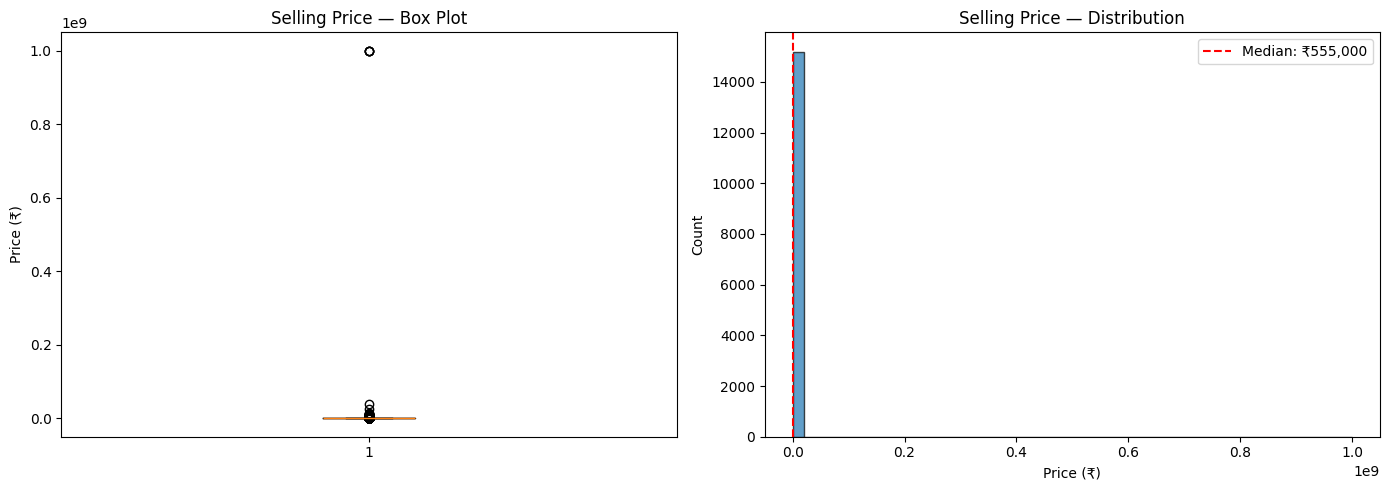

Clearly wrong values:
  Prices = 999999999: 4 rows
  Prices < 1000: 4 rows


In [315]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].boxplot(df['selling_price'].dropna(), vert=True)
axes[0].set_title('Selling Price — Box Plot')
axes[0].set_ylabel('Price (₹)')


axes[1].hist(df['selling_price'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Selling Price — Distribution')
axes[1].set_xlabel('Price (₹)')
axes[1].set_ylabel('Count')
axes[1].axvline(x=df['selling_price'].median(), color='red', linestyle='--', label=f"Median: ₹{df['selling_price'].median():,.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()


print("Clearly wrong values:")
print(f"  Prices = 999999999: {(df['selling_price'] == 999999999).sum()} rows")
print(f"  Prices < 1000: {(df['selling_price'] < 1000).sum()} rows")

In [316]:
df=df[df['selling_price']!=999999999]
df=df[df['selling_price']>=10000]
df=df[df['seats']>0]

print(f"After removing the impossible values new length of dataframe: {len(df)}")

After removing the impossible values new length of dataframe: 15192


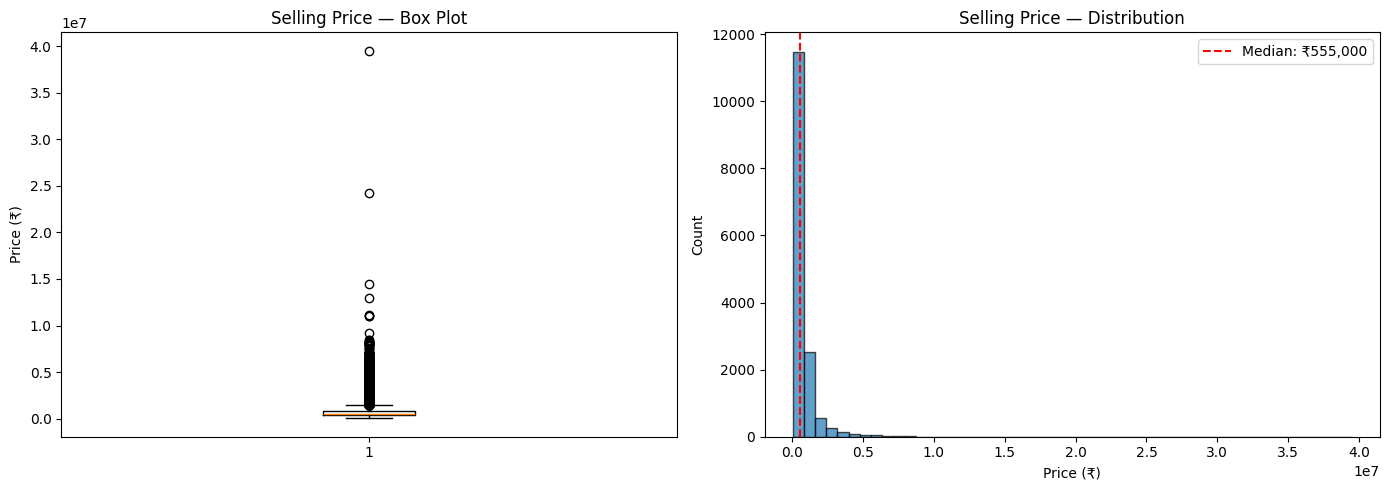

In [317]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].boxplot(df['selling_price'].dropna(), vert=True)
axes[0].set_title('Selling Price — Box Plot')
axes[0].set_ylabel('Price (₹)')


axes[1].hist(df['selling_price'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Selling Price — Distribution')
axes[1].set_xlabel('Price (₹)')
axes[1].set_ylabel('Count')
axes[1].axvline(x=df['selling_price'].median(), color='red', linestyle='--', label=f"Median: ₹{df['selling_price'].median():,.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [318]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 15192 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15192 non-null  object 
 1   brand              15192 non-null  object 
 2   model              15192 non-null  object 
 3   vehicle_age        15192 non-null  int64  
 4   km_driven          15192 non-null  int64  
 5   seller_type        15192 non-null  object 
 6   fuel_type          15192 non-null  object 
 7   transmission_type  15192 non-null  object 
 8   mileage            15192 non-null  float64
 9   engine             15192 non-null  float64
 10  max_power          15192 non-null  float64
 11  seats              15192 non-null  float64
 12  selling_price      15192 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15192.000000,1.519200e+04,15192.000000,15192.000000,15192.000000,15192.000000,1.519200e+04
mean,6.037651,5.562271e+04,19.690979,1453.153436,99.971274,5.315824,7.760790e+05
std,3.014158,5.186574e+04,4.001617,486.515923,41.914202,0.794983,8.986292e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,2.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.097500,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.550000e+05
75%,8.000000,7.000000e+04,22.320000,1498.000000,113.420000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


# Label Encoding
###### Not required here since we are not building an ML model

In [319]:
df.head(10)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,Cng,Manual,33.54,998.0,67.04,5.0,435000.0
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,19.67,1497.0,117.60,5.0,875000.0
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,Dealer,Diesel,Manual,15.40,2179.0,88.50,8.0,925000.0
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.00,2179.0,140.00,7.0,1175000.0
5,Hyundai i10,Hyundai,i10,12,73000,Dealer,Petrol,Manual,20.36,1197.0,78.90,5.0,190000.0
6,Hyundai i20,Hyundai,i20,12,88000,Dealer,Petrol,Manual,18.50,1248.0,80.00,5.0,275000.0
7,Maruti Wagon R,Maruti,Wagon R,7,50000,Individual,Petrol,Manual,20.51,1248.0,67.04,5.0,351000.0
8,Ford Freestyle,Ford,Freestyle,2,30000,Individual,Diesel,Manual,24.40,1498.0,98.63,5.0,775000.0
9,Maruti Swift Dzire,Maruti,Swift Dzire,10,75220,Dealer,Diesel,Manual,19.30,1248.0,73.90,5.0,390000.0


In [320]:
df['seller_type'].unique()

array(['Dealer', 'Individual', 'Trustmark Dealer'], dtype=object)

In [321]:
df['fuel_type'].unique()

array(['Diesel', 'Cng', 'Petrol', 'Lpg', 'Electric'], dtype=object)

In [322]:
df=df.drop(columns=['car_name'])

In [323]:
print(f"no of columns before ONE HOT encoding: {df.shape[1]}")
df=pd.get_dummies(df, columns=['seller_type', 'fuel_type', "brand", "model", "transmission_type"], drop_first=True)
print(f"no of columns after ONE HOT encoding: {df.shape[1]}")

no of columns before ONE HOT encoding: 12
no of columns after ONE HOT encoding: 163


In [324]:
df.head(10)

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,...,model_XF,model_XL6,model_XUV300,model_XUV500,model_Yaris,model_Z4,model_i10,model_i20,model_redi-GO,transmission_type_Manual
0,7,67647,19.87,1461.0,83.80,5.0,575000.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,3,52000,33.54,998.0,67.04,5.0,435000.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,3,48959,19.67,1497.0,117.60,5.0,875000.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,6,82000,15.40,2179.0,88.50,8.0,925000.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,4,34000,16.00,2179.0,140.00,7.0,1175000.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False
5,12,73000,20.36,1197.0,78.90,5.0,190000.0,False,False,False,...,False,False,False,False,False,False,True,False,False,True
6,12,88000,18.50,1248.0,80.00,5.0,275000.0,False,False,False,...,False,False,False,False,False,False,False,True,False,True
7,7,50000,20.51,1248.0,67.04,5.0,351000.0,True,False,False,...,False,False,False,False,False,False,False,False,False,True
8,2,30000,24.40,1498.0,98.63,5.0,775000.0,True,False,True,...,False,False,False,False,False,False,False,False,False,True
9,10,75220,19.30,1248.0,73.90,5.0,390000.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [325]:
X=df.drop(columns=['selling_price'])
y=df['selling_price']

# Task 3 Computing Baseling MAE

In [326]:
mean_price = df["selling_price"].mean()

mae = (df["selling_price"] - mean_price).abs().mean()

print("Baseline MAE:", mae)

Baseline MAE: 454744.40529984847
